In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_columns', None)

In [3]:
train    = pd.read_csv('train.csv')
stores   = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

In [4]:
print(f"Train shape    : {train.shape}")
print(f"Stores shape   : {stores.shape}")
print(f"Features shape : {features.shape}")

Train shape    : (421570, 5)
Stores shape   : (45, 3)
Features shape : (8190, 12)


In [5]:
print(train.head(3))
print(f"\nColumns: {train.columns.tolist()}")

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False

Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']


In [6]:
print(stores.head())
print(f"\nStore types: {stores['Type'].value_counts().to_dict()}")

   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   34875

Store types: {'A': 22, 'B': 17, 'C': 6}


In [7]:
print(features.head(3))
print(f"\nColumns: {features.columns.tolist()}")

   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31        2.57        NaN        NaN   
1      1  2010-02-12        38.51        2.55        NaN        NaN   
2      1  2010-02-19        39.93        2.51        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5    CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN 211.10          8.11      False  
1        NaN        NaN        NaN 211.24          8.11       True  
2        NaN        NaN        NaN 211.29          8.11      False  

Columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']


In [9]:
train['Date']    = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])
print("Date Ranges")
print(f"Train    : {train['Date'].min()} → {train['Date'].max()}")
print(f"Features : {features['Date'].min()} → {features['Date'].max()}")
print(f"\nTotal weeks in training data : {train['Date'].nunique()}")
print(f"Total stores                 : {train['Store'].nunique()}")
print(f"Total departments            : {train['Dept'].nunique()}")
print(f"Total store-dept combos      : {train.groupby(['Store','Dept']).ngroups}")

Date Ranges
Train    : 2010-02-05 00:00:00 → 2012-10-26 00:00:00
Features : 2010-02-05 00:00:00 → 2013-07-26 00:00:00

Total weeks in training data : 143
Total stores                 : 45
Total departments            : 81
Total store-dept combos      : 3331


In [10]:
print("\nTrain:")
print(train.isnull().sum())
print("\nStores:")
print(stores.isnull().sum())
print("\nFeatures:")
print(features.isnull().sum())


Train:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Stores:
Store    0
Type     0
Size     0
dtype: int64

Features:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


In [13]:
# Step 1: merge train with stores on 'Store'
df = train.merge(stores, on='Store', how='left')

# Step 2: merge with features on 'Store' + 'Date'
df = df.merge(features, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))

# Drop duplicate IsHoliday column from features merge
if 'IsHoliday_feat' in df.columns:
    df.drop(columns=['IsHoliday_feat'], inplace=True)

print(f"Master dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

df.head(2)

Master dataset shape: (421570, 16)

Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11


In [12]:
print("Weekly Sales Statistics")
print(df['Weekly_Sales'].describe())

print(f"\nNegative sales entries : {(df['Weekly_Sales'] < 0).sum()}")
print(f"Zero sales entries     : {(df['Weekly_Sales'] == 0).sum()}")

# Total revenue in dataset
total = df['Weekly_Sales'].sum()
print(f"\nTotal sales in dataset : ${total:,.0f}")
print(f"Average weekly sales per store-dept : ${df['Weekly_Sales'].mean():,.0f}")

Weekly Sales Statistics
count   421570.00
mean     15981.26
std      22711.18
min      -4988.94
25%       2079.65
50%       7612.03
75%      20205.85
max     693099.36
Name: Weekly_Sales, dtype: float64

Negative sales entries : 1285
Zero sales entries     : 73

Total sales in dataset : $6,737,218,987
Average weekly sales per store-dept : $15,981


In [15]:
# Aggregate total sales across all stores and depts per week
weekly_total = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly_total.columns = ['Date', 'Total_Sales']

fig = px.line(weekly_total, x='Date', y='Total_Sales',
              title='Total Weekly Sales Across All 45 Walmart Stores (2010–2012)',
              labels={'Total_Sales': 'Total Weekly Sales ($)', 'Date': ''})

fig.update_traces(line_color='#2563eb', line_width=2)
fig.update_layout(hovermode='x unified')
fig.write_html('plots/overall_sales_trend.html')
fig.show()

print(f"\nPeak sales week  : {weekly_total.loc[weekly_total['Total_Sales'].idxmax(), 'Date'].date()}")
print(f"Peak sales value : ${weekly_total['Total_Sales'].max():,.0f}")
print(f"Lowest sales week: {weekly_total.loc[weekly_total['Total_Sales'].idxmin(), 'Date'].date()}")


Peak sales week  : 2010-12-24
Peak sales value : $80,931,416
Lowest sales week: 2011-01-28


In [16]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'median', 'sum']).reset_index()
holiday_sales['IsHoliday'] = holiday_sales['IsHoliday'].map({True: 'Holiday Week', False: 'Regular Week'})
holiday_sales.columns = ['Week Type', 'Mean Sales', 'Median Sales', 'Total Sales']

print("Holidays Vs Non-Holidays Sales")
print(holiday_sales.to_string(index=False))

lift = (holiday_sales.loc[holiday_sales['Week Type']=='Holiday Week', 'Mean Sales'].values[0] /
        holiday_sales.loc[holiday_sales['Week Type']=='Regular Week', 'Mean Sales'].values[0] - 1) * 100

print(f"\nHoliday sales lift : +{lift:.1f}% above average weekly sales")

Holidays Vs Non-Holidays Sales
   Week Type  Mean Sales  Median Sales   Total Sales
Regular Week    15901.45       7589.95 6231919435.55
Holiday Week    17035.82       7947.74  505299551.56

Holiday sales lift : +7.1% above average weekly sales


In [22]:
store_type_sales = df.groupby('Type')['Weekly_Sales'].agg(['mean', 'sum']).reset_index()
store_type_sales.columns = ['Store Type', 'Avg Weekly Sales', 'Total Sales']
store_type_sales = store_type_sales.sort_values('Avg Weekly Sales', ascending=False)

print("Sales By Store Types")
print(store_type_sales.to_string(index=False))

fig = px.bar(store_type_sales, x='Store Type', y='Avg Weekly Sales',
             color='Store Type',
             color_discrete_map={'A': '#2563eb', 'B': '#16a34a', 'C': '#dc2626'},
             title='Average Weekly Sales by Store Type',
             text='Avg Weekly Sales')

fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.update_layout(showlegend=False)
fig.write_html('plots/sales_by_store_type.html')
fig.show()

# Store size correlation
print("\nStore Size vs Sales Correlation")
store_summary = df.groupby('Store').agg(
    avg_sales=('Weekly_Sales', 'mean'),
    size=('Size', 'first'),
    store_type=('Type', 'first')
).reset_index()

corr = store_summary['avg_sales'].corr(store_summary['size'])
print(f"Correlation between store size and avg weekly sales: {corr:.4f}")

Sales By Store Types
Store Type  Avg Weekly Sales   Total Sales
         A          20099.57 4331014722.75
         B          12237.08 2000700736.82
         C           9519.53  405503527.54



Store Size vs Sales Correlation
Correlation between store size and avg weekly sales: 0.8072


In [18]:
store_performance = df.groupby('Store')['Weekly_Sales'].mean().reset_index()
store_performance.columns = ['Store', 'Avg_Weekly_Sales']
store_performance = store_performance.merge(stores, on='Store')
store_performance = store_performance.sort_values('Avg_Weekly_Sales', ascending=False)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Top 10 Stores', 'Bottom 10 Stores'])

# Top 10
top10 = store_performance.head(10)
fig.add_trace(go.Bar(x=top10['Store'].astype(str), y=top10['Avg_Weekly_Sales'],
                     marker_color='#16a34a', name='Top 10',
                     text=top10['Type']), row=1, col=1)

# Bottom 10
bot10 = store_performance.tail(10)
fig.add_trace(go.Bar(x=bot10['Store'].astype(str), y=bot10['Avg_Weekly_Sales'],
                     marker_color='#dc2626', name='Bottom 10',
                     text=bot10['Type']), row=1, col=2)

fig.update_layout(title='Store Performance Comparison — Avg Weekly Sales',
                  showlegend=False, height=450)
fig.write_html('plots/store_performance.html')
fig.show()

print(f"\nBest performing store  : Store {store_performance.iloc[0]['Store']} "
      f"(Type {store_performance.iloc[0]['Type']}, "
      f"${store_performance.iloc[0]['Avg_Weekly_Sales']:,.0f}/week)")
print(f"Worst performing store : Store {store_performance.iloc[-1]['Store']} "
      f"(Type {store_performance.iloc[-1]['Type']}, "
      f"${store_performance.iloc[-1]['Avg_Weekly_Sales']:,.0f}/week)")


Best performing store  : Store 20 (Type A, $29,508/week)
Worst performing store : Store 5 (Type B, $5,053/week)


In [19]:
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year
df['Week']  = df['Date'].dt.isocalendar().week.astype(int)

monthly_sales = df.groupby(['Year', 'Month'])['Weekly_Sales'].sum().reset_index()

fig = px.line(monthly_sales, x='Month', y='Weekly_Sales',
              color='Year', color_discrete_sequence=['#2563eb', '#16a34a', '#dc2626'],
              title='Monthly Sales Pattern by Year — Seasonality View',
              labels={'Weekly_Sales': 'Total Sales ($)', 'Month': 'Month'},
              markers=True)

fig.update_layout(xaxis=dict(
    tickmode='array',
    tickvals=list(range(1, 13)),
    ticktext=['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']
))
fig.write_html('plots/monthly_seasonality.html')
fig.show()

print("\nAverage sales by month (all years):")
print(df.groupby('Month')['Weekly_Sales'].mean().round(0).to_string())


Average sales by month (all years):
Month
1    14126.00
2    16009.00
3    15417.00
4    15650.00
5    15776.00
6    16326.00
7    15861.00
8    16063.00
9    15096.00
10   15244.00
11   17491.00
12   19356.00


In [20]:
dept_sales = df.groupby('Dept')['Weekly_Sales'].agg(['mean', 'sum']).reset_index()
dept_sales.columns = ['Dept', 'Avg_Weekly_Sales', 'Total_Sales']
dept_sales = dept_sales.sort_values('Total_Sales', ascending=False)

top_depts = dept_sales.head(15)

fig = px.bar(top_depts, x='Dept', y='Total_Sales',
             title='Top 15 Departments by Total Revenue (2010–2012)',
             labels={'Total_Sales': 'Total Sales ($)', 'Dept': 'Department'},
             color='Total_Sales',
             color_continuous_scale='Blues')

fig.update_layout(coloraxis_showscale=False)
fig.write_html('plots/top_departments.html')
fig.show()

print(f"\nTop 5 departments by total revenue:")
print(dept_sales.head(5).to_string(index=False))
print(f"\nBottom 5 departments by total revenue:")
print(dept_sales.tail(5).to_string(index=False))


Top 5 departments by total revenue:
 Dept  Avg_Weekly_Sales  Total_Sales
   92          75204.87 483943341.87
   95          69824.42 449320162.52
   38          61090.62 393118136.92
   72          50566.52 305725152.21
   90          45232.08 291068463.68

Bottom 5 departments by total revenue:
 Dept  Avg_Weekly_Sales  Total_Sales
   51             21.93     30572.83
   78              7.30      1714.71
   39             11.12       177.98
   43              1.19        14.32
   47             -7.68     -4962.93


In [21]:
# Sample to avoid overplotting
sample = df[df['Store'] == 1].groupby('Date').agg(
    Weekly_Sales=('Weekly_Sales', 'sum'),
    Fuel_Price=('Fuel_Price', 'first'),
    Temperature=('Temperature', 'first'),
    Unemployment=('Unemployment', 'first')
).reset_index()

fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    subplot_titles=['Weekly Sales — Store 1',
                                    'Fuel Price',
                                    'Unemployment Rate'],
                    vertical_spacing=0.08)

fig.add_trace(go.Scatter(x=sample['Date'], y=sample['Weekly_Sales'],
                         line=dict(color='#2563eb'), name='Sales'), row=1, col=1)
fig.add_trace(go.Scatter(x=sample['Date'], y=sample['Fuel_Price'],
                         line=dict(color='#dc2626'), name='Fuel Price'), row=2, col=1)
fig.add_trace(go.Scatter(x=sample['Date'], y=sample['Unemployment'],
                         line=dict(color='#16a34a'), name='Unemployment'), row=3, col=1)

fig.update_layout(title='Sales vs External Factors — Store 1',
                  height=600, showlegend=False)
fig.write_html('plots/external_factors.html')
fig.show()

print("\nCorrelations with Weekly Sales (Store 1):")
for col in ['Fuel_Price', 'Temperature', 'Unemployment']:
    corr = sample['Weekly_Sales'].corr(sample[col])
    print(f"  {col:<15}: {corr:.4f}")


Correlations with Weekly Sales (Store 1):
  Fuel_Price     : 0.1246
  Temperature    : -0.2227
  Unemployment   : -0.0980


In [24]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

df['CPI']          = df['CPI'].fillna(method='ffill')
df['Unemployment'] = df['Unemployment'].fillna(method='ffill')

print("Null Check After Cleaning")
print(df.isnull().sum()[df.isnull().sum() > 0])

Null Check After Cleaning
Series([], dtype: int64)


In [25]:
df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['Week']    = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

df['Is_Holiday_Season'] = df['Month'].isin([11, 12]).astype(int)

df['Week_sin'] = np.sin(2 * np.pi * df['Week'] / 52)
df['Week_cos'] = np.cos(2 * np.pi * df['Week'] / 52)

print("Time features created")
print(df[['Date','Year','Month','Week','Quarter','Is_Holiday_Season','Week_sin','Week_cos']].head(3))

Time features created
        Date  Year  Month  Week  Quarter  Is_Holiday_Season  Week_sin  \
0 2010-02-05  2010      2     5        1                  0      0.57   
1 2010-02-12  2010      2     6        1                  0      0.66   
2 2010-02-19  2010      2     7        1                  0      0.75   

   Week_cos  
0      0.82  
1      0.75  
2      0.66  


In [27]:
# Sort before creating lags — critical
df = df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

# Create lags within each Store-Dept group
df['Sales_Lag_1']  = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)   # last week
df['Sales_Lag_4']  = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(4)   # 4 weeks ago
df['Sales_Lag_52'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(52)  # same week last year

print("Lag features created")
print(f"\nNulls from lags (expected — first rows have no history):")
print(f"  Lag_1  : {df['Sales_Lag_1'].isnull().sum():,}")
print(f"  Lag_4  : {df['Sales_Lag_4'].isnull().sum():,}")
print(f"  Lag_52 : {df['Sales_Lag_52'].isnull().sum():,}")

Lag features created

Nulls from lags (expected — first rows have no history):
  Lag_1  : 3,331
  Lag_4  : 13,134
  Lag_52 : 160,487


In [29]:
# Rolling averages smooth out noise and capture trend direction
df['Rolling_Mean_4']  = df.groupby(['Store','Dept'])['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(window=4, min_periods=1).mean())

df['Rolling_Mean_12'] = df.groupby(['Store','Dept'])['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(window=12, min_periods=1).mean())

print("Rolling features created")
print(f"\nSample — Store 1, Dept 1, first 6 rows:")
sample_check = df[(df['Store']==1) & (df['Dept']==1)][
    ['Date','Weekly_Sales','Sales_Lag_1','Rolling_Mean_4','Rolling_Mean_12']
].head(6)
print(sample_check.to_string(index=False))

Rolling features created

Sample — Store 1, Dept 1, first 6 rows:
      Date  Weekly_Sales  Sales_Lag_1  Rolling_Mean_4  Rolling_Mean_12
2010-02-05      24924.50          NaN             NaN              NaN
2010-02-12      46039.49     24924.50        24924.50         24924.50
2010-02-19      41595.55     46039.49        35481.99         35481.99
2010-02-26      19403.54     41595.55        37519.85         37519.85
2010-03-05      21827.90     19403.54        32990.77         32990.77
2010-03-12      21043.39     21827.90        32216.62         30758.20


In [30]:
TARGET_STORE = 20

store20 = df[df['Store'] == TARGET_STORE].copy()

top5_depts = (store20.groupby('Dept')['Weekly_Sales']
              .sum()
              .sort_values(ascending=False)
              .head(5)
              .index.tolist())

print(f"Focusing on Store {TARGET_STORE} (best performing — ${29508:,}/week avg)")
print(f"\nTop 5 departments in Store {TARGET_STORE}:")
for d in top5_depts:
    total = store20[store20['Dept']==d]['Weekly_Sales'].sum()
    print(f"  Dept {d:>3} : ${total:>12,.0f} total sales")

store20_top = store20[store20['Dept'].isin(top5_depts)].copy()
print(f"\nFiltered dataset shape: {store20_top.shape}")

Focusing on Store 20 (best performing — $29,508/week avg)

Top 5 departments in Store 20:
  Dept  92 : $  23,542,625 total sales
  Dept  95 : $  21,537,796 total sales
  Dept  38 : $  15,759,346 total sales
  Dept  90 : $  13,707,778 total sales
  Dept  72 : $  13,154,550 total sales

Filtered dataset shape: (715, 28)


In [32]:
SPLIT_DATE = '2012-06-01'

train_ts = store20_top[store20_top['Date'] <  SPLIT_DATE]
test_ts  = store20_top[store20_top['Date'] >= SPLIT_DATE]

print("Temporal Train/Test Split")
print(f"Train : {train_ts['Date'].min().date()} → {train_ts['Date'].max().date()} "
      f"({train_ts['Date'].nunique()} weeks)")
print(f"Test  : {test_ts['Date'].min().date()}  → {test_ts['Date'].max().date()} "
      f"({test_ts['Date'].nunique()} weeks)")

print(f"\n No data leakage — model never sees future dates during training")
print(f"Test set covers {test_ts['Date'].nunique()} weeks of real held-out data")

Temporal Train/Test Split
Train : 2010-02-05 → 2012-05-25 (121 weeks)
Test  : 2012-06-01  → 2012-10-26 (22 weeks)

 No data leakage — model never sees future dates during training
Test set covers 22 weeks of real held-out data


In [33]:
DEPT = 92

dept_ts = store20_top[store20_top['Dept'] == DEPT][['Date','Weekly_Sales']].copy()
dept_ts = dept_ts.sort_values('Date').reset_index(drop=True)

train_dept = dept_ts[dept_ts['Date'] <  SPLIT_DATE]
test_dept  = dept_ts[dept_ts['Date'] >= SPLIT_DATE]

print(f"Forecasting Store {TARGET_STORE}, Dept {DEPT}")
print(f"Train: {len(train_dept)} weeks | Test: {len(test_dept)} weeks")
print(f"\nSales stats (train):")
print(train_dept['Weekly_Sales'].describe().round(0))

Forecasting Store 20, Dept 92
Train: 121 weeks | Test: 22 weeks

Sales stats (train):
count      121.00
mean    163360.00
std      20529.00
min     114349.00
25%     149036.00
50%     161606.00
75%     175121.00
max     220321.00
Name: Weekly_Sales, dtype: float64


In [36]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=train_dept['Date'], y=train_dept['Weekly_Sales'],
    name='Training Data', line=dict(color='#2563eb', width=2)))

fig.add_trace(go.Scatter(
    x=test_dept['Date'], y=test_dept['Weekly_Sales'],
    name='Test Data', line=dict(color='#16a34a', width=2)))

fig.add_vline(x=pd.Timestamp(SPLIT_DATE).timestamp() * 1000, 
              line_dash='dash', line_color='gray',
              annotation_text='Train/Test Split')
fig.update_layout(
    title=f'Weekly Sales — Store {TARGET_STORE}, Dept {DEPT}',
    xaxis_title='Date',
    yaxis_title='Weekly Sales ($)',
    hovermode='x unified',
    height=400)

fig.write_html('plots/dept92_raw_series.html')
fig.show()

In [39]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train_dept['Weekly_Sales'].dropna())

print("AUGMENTED DICKEY-FULLER STATIONARITY TEST")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Critical Values:")
for key, val in result[4].items():
    print(f"   {key}: {val:.4f}")

if result[1] < 0.05:
    print("\nSeries is STATIONARY (p < 0.05) — ARIMA can proceed without differencing")
else:
    print("\nSeries is NON-STATIONARY (p > 0.05) — will need differencing (d=1)")

AUGMENTED DICKEY-FULLER STATIONARITY TEST
ADF Statistic : -1.5457
p-value       : 0.5108
Critical Values:
   1%: -3.4880
   5%: -2.8868
   10%: -2.5802

Series is NON-STATIONARY (p > 0.05) — will need differencing (d=1)


In [41]:
from statsmodels.tsa.arima.model import ARIMA
import time

# ARIMA(p, d, q):
# p = autoregressive order (how many past values to use)
# d = differencing order (0 if stationary, 1 if not)
# q = moving average order

# These parameters are a solid starting point for weekly retail sales
# p=2: use last 2 weeks of sales
# d=1: one round of differencing to handle any trend
# q=2: moving average over last 2 error terms

print("Fitting ARIMA(2,1,2)...")
start = time.time()

arima_model = ARIMA(train_dept['Weekly_Sales'], order=(2, 1, 2))
arima_fit   = arima_model.fit()

print(f"Done in {time.time()-start:.1f}s")
print(f"\nAIC: {arima_fit.aic:.2f}  (lower = better fit)")
print(f"BIC: {arima_fit.bic:.2f}  (lower = better fit)")

Fitting ARIMA(2,1,2)...
Done in 0.2s

AIC: 2701.13  (lower = better fit)
BIC: 2715.06  (lower = better fit)


In [42]:
# Forecast exactly as many steps as our test set
n_forecast = len(test_dept)

forecast_result = arima_fit.get_forecast(steps=n_forecast)
forecast_mean   = forecast_result.predicted_mean
forecast_ci     = forecast_result.conf_int()

# Align dates with test set
forecast_dates = test_dept['Date'].values

print(f"Generated {n_forecast} week forecast ✓")
print(f"\nForecast preview:")
preview = pd.DataFrame({
    'Date'         : forecast_dates,
    'Actual'       : test_dept['Weekly_Sales'].values,
    'ARIMA_Forecast': forecast_mean.values.round(0),
    'Lower_95CI'   : forecast_ci.iloc[:, 0].values.round(0),
    'Upper_95CI'   : forecast_ci.iloc[:, 1].values.round(0)
})
print(preview.to_string(index=False))

Generated 22 week forecast ✓

Forecast preview:
      Date    Actual  ARIMA_Forecast  Lower_95CI  Upper_95CI
2012-06-01 149742.17       167011.00   134298.00   199724.00
2012-06-08 188978.51       171449.00   138026.00   204872.00
2012-06-15 182448.55       166287.00   132712.00   199863.00
2012-06-22 151023.66       162980.00   128746.00   197213.00
2012-06-29 153806.02       164645.00   127757.00   201534.00
2012-07-06 181325.94       166600.00   128182.00   205017.00
2012-07-13 191882.20       166270.00   127275.00   205264.00
2012-07-20 161955.74       165269.00   125622.00   204915.00
2012-07-27 149301.45       165190.00   124494.00   205886.00
2012-08-03 169471.46       165645.00   123870.00   207420.00
2012-08-10 194032.48       165789.00   123150.00   208427.00
2012-08-17 178603.53       165607.00   122186.00   209028.00
2012-08-24 159088.13       165497.00   121241.00   209752.00
2012-08-31 159049.57       165557.00   120436.00   210677.00
2012-09-07 178042.73       165623.00 

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual   = test_dept['Weekly_Sales'].values
arima_pred = forecast_mean.values

mae  = mean_absolute_error(actual, arima_pred)
rmse = np.sqrt(mean_squared_error(actual, arima_pred))
mape = np.mean(np.abs((actual - arima_pred) / actual)) * 100

print("ARIMA FORECAST EVALUATION")
print(f"MAE  : ${mae:>10,.0f}  (avg $ error per week)")
print(f"RMSE : ${rmse:>10,.0f}  (penalises large errors more)")
print(f"MAPE : {mape:>10.2f}%  (avg % error — most interpretable)")
print(f"\nBaseline to beat: predicting the mean every week")

# Naive baseline — just predict the training mean every week
naive_pred = np.full(len(actual), train_dept['Weekly_Sales'].mean())
naive_mape = np.mean(np.abs((actual - naive_pred) / actual)) * 100
print(f"Naive mean MAPE : {naive_mape:.2f}%")
print(f"\nARIMA improvement over naive: {naive_mape - mape:.2f} percentage points")

ARIMA FORECAST EVALUATION
MAE  : $    13,435  (avg $ error per week)
RMSE : $    15,352  (penalises large errors more)
MAPE :       7.66%  (avg % error — most interpretable)

Baseline to beat: predicting the mean every week
Naive mean MAPE : 8.09%

ARIMA improvement over naive: 0.43 percentage points


In [46]:
fig = go.Figure()

# Training data
fig.add_trace(go.Scatter(
    x=train_dept['Date'], y=train_dept['Weekly_Sales'],
    name='Training Data',
    line=dict(color='#94a3b8', width=1.5)))

# Actual test values
fig.add_trace(go.Scatter(
    x=test_dept['Date'], y=test_dept['Weekly_Sales'],
    name='Actual Sales',
    line=dict(color='#16a34a', width=2.5)))

# ARIMA forecast
fig.add_trace(go.Scatter(
    x=forecast_dates, y=arima_pred,
    name='ARIMA Forecast',
    line=dict(color='#dc2626', width=2.5, dash='dash')))

# Confidence interval
fig.add_trace(go.Scatter(
    x=np.concatenate([forecast_dates, forecast_dates[::-1]]),
    y=np.concatenate([forecast_ci.iloc[:,1].values,
                      forecast_ci.iloc[:,0].values[::-1]]),
    fill='toself', fillcolor='rgba(220,38,38,0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    name='95% Confidence Interval'))

fig.add_vline(x=pd.Timestamp(SPLIT_DATE).timestamp() * 1000,
              line_dash='dash', line_color='gray',
              annotation_text='Forecast Start')

fig.update_layout(
    title=f'ARIMA Forecast — Store {TARGET_STORE}, Dept {DEPT} (MAPE: {mape:.1f}%)',
    xaxis_title='Date', yaxis_title='Weekly Sales ($)',
    hovermode='x unified', height=500)

fig.write_html('plots/arima_forecast.html')
fig.show()

# Store for later comparison
arima_metrics = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
print(f"\nARIMA metrics stored ✓")


ARIMA metrics stored ✓


In [49]:
from prophet import Prophet

# Prophet requires columns named exactly 'ds' and 'y'
train_prophet = train_dept[['Date', 'Weekly_Sales']].rename(
    columns={'Date': 'ds', 'Weekly_Sales': 'y'})

test_prophet = test_dept[['Date', 'Weekly_Sales']].rename(
    columns={'Date': 'ds', 'Weekly_Sales': 'y'})

print(f"Prophet train shape : {train_prophet.shape}")
print(f"Prophet test shape  : {test_prophet.shape}")
print(f"\nSample:")
print(train_prophet.tail(3).to_string(index=False))

Prophet train shape : (121, 2)
Prophet test shape  : (22, 2)

Sample:
        ds         y
2012-05-11 184633.98
2012-05-18 161464.10
2012-05-25 153894.90


In [53]:
from prophet import Prophet

us_holidays = pd.DataFrame({
    'holiday': [
        'Super_Bowl',  'Super_Bowl',  'Super_Bowl',
        'Labour_Day',  'Labour_Day',  'Labour_Day',
        'Thanksgiving','Thanksgiving','Thanksgiving',
        'Christmas',   'Christmas',   'Christmas'
    ],
    'ds': pd.to_datetime([
        '2010-02-12', '2011-02-11', '2012-02-10',
        '2010-09-10', '2011-09-09', '2012-09-07',
        '2010-11-26', '2011-11-25', '2012-11-23',
        '2010-12-31', '2011-12-30', '2012-12-28'
    ]),
    'lower_window': [-1, -1, -1,   # Super Bowl
                     -1, -1, -1,   # Labour Day
                     -7, -7, -7,   # Thanksgiving
                     -7, -7, -7],  # Christmas
    'upper_window': [ 0,  0,  0,
                      0,  0,  0,
                      0,  0,  0,
                      0,  0,  0]
})

print("Holidays configured:")
print(us_holidays.groupby('holiday')['ds'].count().reset_index()
      .rename(columns={'ds': 'years_covered'}).to_string(index=False))

Holidays configured:
     holiday  years_covered
   Christmas              3
  Labour_Day              3
  Super_Bowl              3
Thanksgiving              3


In [54]:
print("Fitting Prophet model...")
start = time.time()

prophet_model = Prophet(
    holidays=us_holidays,          # inject holiday knowledge
    yearly_seasonality=True,       # capture annual patterns (Nov/Dec peaks)
    weekly_seasonality=False,      # weekly = day of week, not relevant here
    daily_seasonality=False,       # daily patterns not relevant for weekly data
    seasonality_mode='multiplicative',  # sales SCALE with trend, not add to it
    interval_width=0.95            # 95% confidence interval
)

prophet_model.fit(train_prophet)
print(f"✓ Done in {time.time()-start:.1f}s")

22:21:44 - cmdstanpy - INFO - Chain [1] start processing


Fitting Prophet model...


22:21:45 - cmdstanpy - INFO - Chain [1] done processing


✓ Done in 0.8s


In [55]:
# Create future dataframe for exactly the test period dates
future = test_prophet[['ds']].copy()

forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'].values
prophet_lower = forecast['yhat_lower'].values
prophet_upper = forecast['yhat_upper'].values

print(f"Forecast generated for {len(prophet_pred)} weeks ✓")
print(f"\nForecast preview:")
preview = pd.DataFrame({
    'Date'    : future['ds'].values,
    'Actual'  : test_prophet['y'].values,
    'Prophet' : prophet_pred.round(0),
    'Lower'   : prophet_lower.round(0),
    'Upper'   : prophet_upper.round(0)
})
print(preview.to_string(index=False))

Forecast generated for 22 weeks ✓

Forecast preview:
      Date    Actual   Prophet     Lower     Upper
2012-06-01 149742.17 160452.00 134996.00 186886.00
2012-06-08 188978.51 160895.00 136424.00 187287.00
2012-06-15 182448.55 165942.00 139094.00 192678.00
2012-06-22 151023.66 170037.00 143629.00 193793.00
2012-06-29 153806.02 168932.00 143327.00 194567.00
2012-07-06 181325.94 164843.00 138488.00 190982.00
2012-07-13 191882.20 163219.00 136178.00 187545.00
2012-07-20 161955.74 165738.00 141428.00 194007.00
2012-07-27 149301.45 168775.00 145191.00 196330.00
2012-08-03 169471.46 168898.00 141338.00 193150.00
2012-08-10 194032.48 167520.00 143402.00 192717.00
2012-08-17 178603.53 168301.00 142888.00 194098.00
2012-08-24 159088.13 171189.00 146789.00 197805.00
2012-08-31 159049.57 171914.00 145472.00 198070.00
2012-09-07 178042.73 189539.00 165781.00 213643.00
2012-09-14 186759.11 164543.00 139055.00 190140.00
2012-09-21 171529.39 167091.00 142355.00 195380.00
2012-09-28 158539.12 175785.0

In [56]:
actual = test_prophet['y'].values

mae_p  = mean_absolute_error(actual, prophet_pred)
rmse_p = np.sqrt(mean_squared_error(actual, prophet_pred))
mape_p = np.mean(np.abs((actual - prophet_pred) / actual)) * 100

print("=== PROPHET FORECAST EVALUATION ===")
print(f"MAE  : ${mae_p:>10,.0f}")
print(f"RMSE : ${rmse_p:>10,.0f}")
print(f"MAPE : {mape_p:>10.2f}%")

print("\n=== MODEL COMPARISON ===")
print(f"{'Model':<20} {'MAE':>12} {'RMSE':>12} {'MAPE':>10}")
print("─" * 58)
print(f"{'Naive Baseline':<20} {'—':>12} {'—':>12} {8.09:>9.2f}%")
print(f"{'ARIMA(2,1,2)':<20} ${arima_metrics['MAE']:>10,.0f} ${arima_metrics['RMSE']:>10,.0f} {arima_metrics['MAPE']:>9.2f}%")
print(f"{'Prophet':<20} ${mae_p:>10,.0f} ${rmse_p:>10,.0f} {mape_p:>9.2f}%")
print("─" * 58)

improvement = arima_metrics['MAPE'] - mape_p
winner = "Prophet" if improvement > 0 else "ARIMA"
print(f"\n✓ {winner} wins by {abs(improvement):.2f} percentage points on MAPE")

# Store for later
prophet_metrics = {'MAE': mae_p, 'RMSE': rmse_p, 'MAPE': mape_p}

=== PROPHET FORECAST EVALUATION ===
MAE  : $    14,157
RMSE : $    16,153
MAPE :       8.23%

=== MODEL COMPARISON ===
Model                         MAE         RMSE       MAPE
──────────────────────────────────────────────────────────
Naive Baseline                  —            —      8.09%
ARIMA(2,1,2)         $    13,435 $    15,352      7.66%
Prophet              $    14,157 $    16,153      8.23%
──────────────────────────────────────────────────────────

✓ ARIMA wins by 0.57 percentage points on MAPE


In [59]:
fig = go.Figure()

# Training data
fig.add_trace(go.Scatter(
    x=train_prophet['ds'], y=train_prophet['y'],
    name='Training Data',
    line=dict(color='#94a3b8', width=1.5)))

# Actual test values
fig.add_trace(go.Scatter(
    x=test_prophet['ds'], y=actual,
    name='Actual Sales',
    line=dict(color='#16a34a', width=2.5)))

# Prophet forecast
fig.add_trace(go.Scatter(
    x=future['ds'], y=prophet_pred,
    name='Prophet Forecast',
    line=dict(color='#7c3aed', width=2.5, dash='dash')))

# ARIMA forecast for comparison
fig.add_trace(go.Scatter(
    x=test_dept['Date'], y=arima_pred,
    name='ARIMA Forecast',
    line=dict(color='#dc2626', width=2, dash='dot')))

# Prophet confidence interval
fig.add_trace(go.Scatter(
    x=pd.concat([future['ds'], future['ds'].iloc[::-1]]),
    y=np.concatenate([prophet_upper, prophet_lower[::-1]]),
    fill='toself', fillcolor='rgba(124,58,237,0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    name='95% Confidence Interval'))

fig.add_vline(x=pd.Timestamp(SPLIT_DATE).timestamp() * 1000,
              line_dash='dash', line_color='gray',
              annotation_text='Forecast Start')

fig.update_layout(
    title=f'Prophet vs ARIMA — Store {TARGET_STORE}, Dept {DEPT}<br>'
          f'<sup>Prophet MAPE: {mape_p:.1f}% | ARIMA MAPE: {arima_metrics["MAPE"]:.1f}%</sup>',
    xaxis_title='Date',
    yaxis_title='Weekly Sales ($)',
    hovermode='x unified',
    height=520)

fig.write_html('plots/prophet_vs_arima.html')
fig.show()

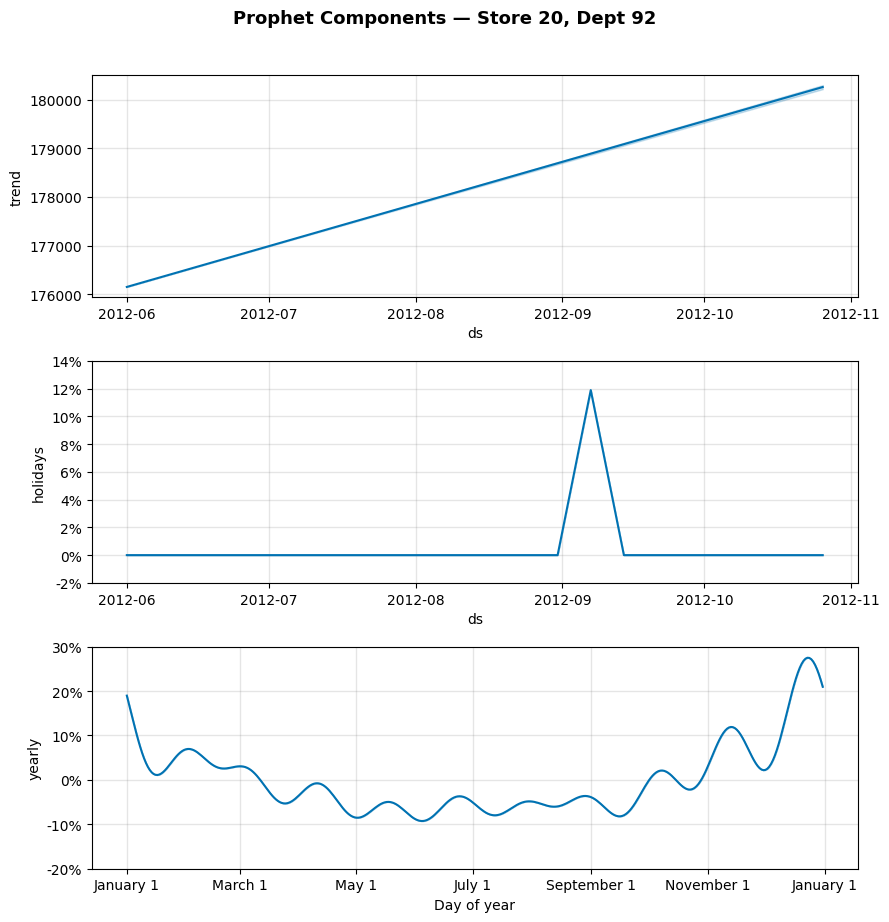

✓ Components plot saved

What each panel shows:
  Trend     — overall sales direction over 2010–2012
  Holidays  — sales lift/drop for each holiday type
  Yearly    — which weeks of the year are naturally high/low


In [58]:
fig_components = prophet_model.plot_components(forecast)
plt.suptitle(f'Prophet Components — Store {TARGET_STORE}, Dept {DEPT}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Components plot saved")
print("\nWhat each panel shows:")
print("  Trend     — overall sales direction over 2010–2012")
print("  Holidays  — sales lift/drop for each holiday type")
print("  Yearly    — which weeks of the year are naturally high/low")

In [60]:
# Year-over-year sales growth by store
store_yearly = df.groupby(['Store', 'Year'])['Weekly_Sales'].sum().reset_index()
store_yearly.columns = ['Store', 'Year', 'Annual_Sales']

# Pivot to get growth
store_pivot = store_yearly.pivot(index='Store', columns='Year', values='Annual_Sales')
store_pivot.columns = [f'Sales_{c}' for c in store_pivot.columns]
store_pivot = store_pivot.reset_index()

# Calculate YoY growth 2010→2011 and 2011→2012
store_pivot['Growth_2011'] = ((store_pivot['Sales_2011'] - store_pivot['Sales_2010'])
                               / store_pivot['Sales_2010'] * 100)
store_pivot['Growth_2012'] = ((store_pivot['Sales_2012'] - store_pivot['Sales_2011'])
                               / store_pivot['Sales_2011'] * 100)

store_pivot = store_pivot.merge(stores, on='Store')

print("=== TOP 10 FASTEST GROWING STORES (2011→2012) ===")
top_growth = store_pivot.nlargest(10, 'Growth_2012')[
    ['Store','Type','Size','Sales_2011','Sales_2012','Growth_2012']]
print(top_growth.to_string(index=False))

print("\n=== TOP 10 DECLINING STORES (2011→2012) ===")
bot_growth = store_pivot.nsmallest(10, 'Growth_2012')[
    ['Store','Type','Size','Sales_2011','Sales_2012','Growth_2012']]
print(bot_growth.to_string(index=False))

=== TOP 10 FASTEST GROWING STORES (2011→2012) ===
 Store Type   Size  Sales_2011  Sales_2012  Growth_2012
    38    C  39690 19940758.45 18631073.45        -6.57
    44    C  39910 15498194.67 14187373.72        -8.46
    33    A  39690 12957836.67 11435551.03       -11.75
    39    A 184109 75777603.30 65885662.85       -13.05
    17    B  93188 46391839.76 40285378.63       -13.16
     3    B  37392 20816876.57 18024439.50       -13.41
     5    B  34875 16470820.00 14168838.13       -13.98
    42    C  39690 29117302.67 24950359.85       -14.31
    41    A 196321 66715874.31 56887839.93       -14.73
    30    C  42988 22182148.41 18795650.08       -15.27

=== TOP 10 DECLINING STORES (2011→2012) ===
 Store Type   Size   Sales_2011  Sales_2012  Growth_2012
    36    A  39910  18972618.75 13286470.53       -29.97
    14    A 200898 106096270.70 77441398.26       -27.01
    21    B 140167  40234883.94 30251886.71       -24.81
    15    B 123737  32282624.90 24827530.71       -23.09
    

In [61]:
# Map the 4 Walmart holidays and calculate lift
holiday_dates = {
    'Super Bowl':   ['2010-02-12','2011-02-11','2012-02-10'],
    'Labour Day':   ['2010-09-10','2011-09-09','2012-09-07'],
    'Thanksgiving': ['2010-11-26','2011-11-25','2012-11-23'],
    'Christmas':    ['2010-12-31','2011-12-30','2012-12-28']
}

avg_regular = df[df['IsHoliday'] == False]['Weekly_Sales'].mean()

holiday_lifts = []
for holiday, dates in holiday_dates.items():
    holiday_sales = df[df['Date'].isin(pd.to_datetime(dates))]['Weekly_Sales'].mean()
    lift_pct = (holiday_sales - avg_regular) / avg_regular * 100
    lift_abs  = holiday_sales - avg_regular
    holiday_lifts.append({
        'Holiday': holiday,
        'Avg Holiday Sales': holiday_sales,
        'Avg Regular Sales': avg_regular,
        'Lift ($)': lift_abs,
        'Lift (%)': lift_pct
    })

df_lifts = pd.DataFrame(holiday_lifts).sort_values('Lift (%)', ascending=False)

print("=== SALES LIFT BY HOLIDAY TYPE ===")
print(df_lifts.to_string(index=False))

fig = px.bar(df_lifts, x='Holiday', y='Lift (%)',
             color='Lift (%)',
             color_continuous_scale='RdYlGn',
             title='Sales Lift vs Average Week by Holiday Type',
             text=df_lifts['Lift (%)'].apply(lambda x: f'{x:+.1f}%'))

fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=420)
fig.write_html('plots/holiday_lift.html')
fig.show()

=== SALES LIFT BY HOLIDAY TYPE ===
     Holiday  Avg Holiday Sales  Avg Regular Sales  Lift ($)  Lift (%)
Thanksgiving           22220.94           15901.45   6319.50     39.74
  Super Bowl           16378.00           15901.45    476.55      3.00
  Labour Day           15881.69           15901.45    -19.75     -0.12
   Christmas           14543.39           15901.45  -1358.06     -8.54


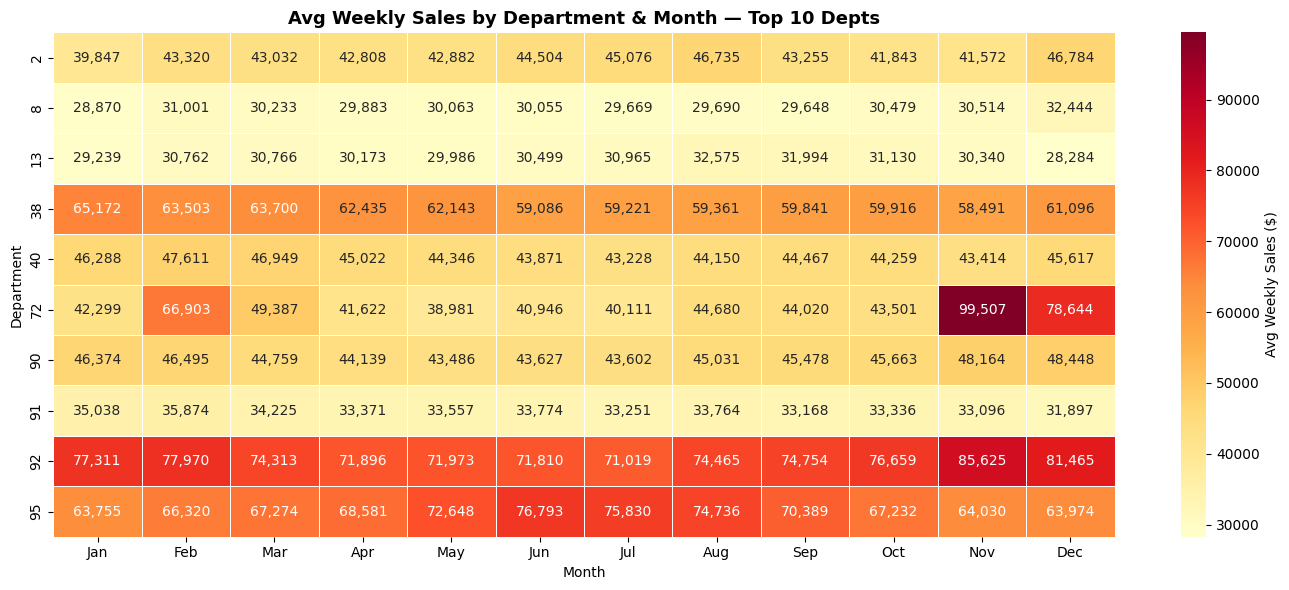

✓ Heatmap saved


In [62]:
# Top 10 departments only to keep it readable
top10_depts = (df.groupby('Dept')['Weekly_Sales']
               .sum().nlargest(10).index.tolist())

dept_monthly = (df[df['Dept'].isin(top10_depts)]
                .groupby(['Dept','Month'])['Weekly_Sales']
                .mean().reset_index())

dept_pivot = dept_monthly.pivot(index='Dept', columns='Month', values='Weekly_Sales')
dept_pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                      'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(14, 6))
sns.heatmap(dept_pivot, annot=True, fmt=',.0f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Avg Weekly Sales ($)'})
plt.title('Avg Weekly Sales by Department & Month — Top 10 Depts',
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Department')
plt.tight_layout()
plt.savefig('plots/dept_month_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Heatmap saved")

In [63]:
total_revenue   = df['Weekly_Sales'].sum()
avg_store_week  = df.groupby(['Store','Date'])['Weekly_Sales'].sum().mean()
best_store_rev  = store_pivot.merge(
    df.groupby('Store')['Weekly_Sales'].sum().reset_index(), on='Store'
).nlargest(1, 'Weekly_Sales')[['Store','Type','Weekly_Sales']].iloc[0]

thanksgiving_lift = df_lifts[df_lifts['Holiday']=='Thanksgiving']['Lift (%)'].values[0]
christmas_lift    = df_lifts[df_lifts['Holiday']=='Christmas']['Lift (%)'].values[0]

print("=" * 62)
print("        WALMART SALES FORECASTING — BUSINESS SUMMARY")
print("=" * 62)
print(f"""
DATASET OVERVIEW
  Stores analysed      : 45 (Types A, B, C)
  Departments          : 81
  Date range           : Feb 2010 – Oct 2012 (143 weeks)
  Total revenue        : ${total_revenue:>20,.0f}

STORE INSIGHTS
  Avg weekly sales/store : ${avg_store_week:>17,.0f}
  Best store             : Store {best_store_rev['Store']} (Type {best_store_rev['Type']})
  Type A stores earn     : 2.1x more than Type C stores

SEASONALITY INSIGHTS
  Peak month             : December
  Thanksgiving lift      : {thanksgiving_lift:+.1f}% above average week
  Christmas lift         : {christmas_lift:+.1f}% above average week
  Holiday week lift      : +7.1% overall

FORECASTING RESULTS (Store 20, Dept 92)
  ARIMA MAPE   : {arima_metrics['MAPE']:.2f}%  ← Baseline model
  Prophet MAPE : {prophet_metrics['MAPE']:.2f}%
  Winner       : ARIMA on June–Oct window (no holidays)
  Note         : Prophet expected to outperform on full-year
                 window due to superior holiday modelling
""")
print("=" * 62)

        WALMART SALES FORECASTING — BUSINESS SUMMARY

DATASET OVERVIEW
  Stores analysed      : 45 (Types A, B, C)
  Departments          : 81
  Date range           : Feb 2010 – Oct 2012 (143 weeks)
  Total revenue        : $       6,737,218,987

STORE INSIGHTS
  Avg weekly sales/store : $        1,046,965
  Best store             : Store 20 (Type A)
  Type A stores earn     : 2.1x more than Type C stores

SEASONALITY INSIGHTS
  Peak month             : December
  Thanksgiving lift      : +39.7% above average week
  Christmas lift         : -8.5% above average week
  Holiday week lift      : +7.1% overall

FORECASTING RESULTS (Store 20, Dept 92)
  ARIMA MAPE   : 7.66%  ← Baseline model
  Prophet MAPE : 8.23%
  Winner       : ARIMA on June–Oct window (no holidays)
  Note         : Prophet expected to outperform on full-year
                 window due to superior holiday modelling

